In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')  # run from project root for data/, outputs/
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read data and display the overall picture

### Read data and display its basic structure

In [2]:
# Read averaged data
df_averaged = pd.read_csv("outputs/fitting_plots/run_best_models_averaged_20260227_201811.csv")

# Read raw per-run data
#df_raw = pd.read_csv("outputs/fitting_plots/run_best_models_20260227_201811.csv")

# display data
print(df_averaged.columns)
df_averaged.head()

Index(['timestamp', 'mode', 'U2', 'RF_amplitude', 'line_id', 'rep', 'min_scan',
       'max_scan', 'n_peaks', 'r2', 'aicc', 'c0', 'amp1', 'mu1', 'sigma1',
       'amp2', 'mu2', 'sigma2', 'amp3', 'mu3', 'sigma3', 'amp4', 'mu4',
       'sigma4', 'amp5', 'mu5', 'sigma5', 'amp6', 'mu6', 'sigma6', 'amp7',
       'mu7', 'sigma7', 'amp8', 'mu8', 'sigma8', 'amp9', 'mu9', 'sigma9',
       'amp10', 'mu10', 'sigma10', 'amp11', 'mu11', 'sigma11', 'amp12', 'mu12',
       'sigma12', 'amp13', 'mu13', 'sigma13', 'amp14', 'mu14', 'sigma14',
       'amp15', 'mu15', 'sigma15', 'amp16', 'mu16', 'sigma16', 'amp17', 'mu17',
       'sigma17', 'amp18', 'mu18', 'sigma18', 'RF_setpoint_dBm',
       'RF_act_trimmed_dBm'],
      dtype='object')


,timestamp,mode,U2,RF_amplitude,line_id,rep,min_scan,max_scan,n_peaks,r2,...,mu16,sigma16,amp17,mu17,sigma17,amp18,mu18,sigma18,RF_setpoint_dBm,RF_act_trimmed_dBm
0,averaged,lost,-0.35,-0.5,0,avg,20.0,140.0,17,0.992405,...,87.258470,4.019964,0.003149,124.276782,0.5,NaN,NaN,NaN,-0.5,9.925784
1,averaged,trapped,-0.35,-0.5,0,avg,20.0,140.0,16,0.972366,...,93.393226,1.369044,NaN,NaN,NaN,NaN,NaN,NaN,-0.5,9.925784
2,averaged,lost,-0.35,0.0,0,avg,20.0,140.0,14,0.994047,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,10.330446
3,averaged,trapped,-0.35,0.0,0,avg,20.0,140.0,15,0.961303,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,10.330446
4,averaged,lost,-0.35,0.2,0,avg,20.0,140.0,14,0.992710,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,10.450421


### Arrange the data for easier access

In [3]:
def dBm_to_mW(dBm):
    """Convert dBm to mW: mW = 10^(dBm/10)"""
    return 10 ** (np.asarray(dBm) / 10)

# Process df_averaged, convert columns and rearrange before splitting
df = df_averaged.copy()

# Convert: dBm -> mW
df["RF_set_mW"] = dBm_to_mW(df["RF_amplitude"])
df["act_RF_mW"] = dBm_to_mW(df["RF_act_trimmed_dBm"])

# Rename Columns
df = df.rename(columns={
    "RF_act_trimmed_dBm": "RF_meas_dBm",
    "RF_amplitude": "RF_set_dBm"
})

# Drop the redundant RF_setpoint_dBm (same as RF_set_dBm)
df = df.drop(columns=["RF_setpoint_dBm"], errors="ignore")

# Reorder columns: insert RF_set_dBm, RF_set_mW, RF_meas_dBm, act_RF_mW after U2 and before line_id
rf_cols = ["RF_set_dBm", "RF_set_mW", "RF_meas_dBm", "act_RF_mW"]
cols = [c for c in df.columns if c not in rf_cols]
idx_u2 = cols.index("U2")
idx_line = cols.index("line_id")
new_order = cols[: idx_u2 + 1] + rf_cols + cols[idx_u2 + 1 : idx_line] + cols[idx_line :]
df = df[new_order]

# Split into trapped and lost
df_lost = df[df["mode"] == "lost"].reset_index(drop=True)
df_trapped = df[df["mode"] == "trapped"].reset_index(drop=True)

print("df_lost shape:", df_lost.shape)
print("df_trapped shape:", df_trapped.shape)
idx_line_new = new_order.index("line_id")
print("\nColumn order (U2 -> line_id):", new_order[idx_u2 : idx_line_new + 1])
df_lost[["U2", "RF_set_dBm", "RF_set_mW", "RF_meas_dBm", "act_RF_mW", "line_id"]].head()

# Display the new DataFrame
print(df_lost.columns)
df_lost.head()

df_lost shape: (20, 69)
df_trapped shape: (20, 69)

Column order (U2 -> line_id): ['U2', 'RF_set_dBm', 'RF_set_mW', 'RF_meas_dBm', 'act_RF_mW', 'line_id']
Index(['timestamp', 'mode', 'U2', 'RF_set_dBm', 'RF_set_mW', 'RF_meas_dBm',
       'act_RF_mW', 'line_id', 'rep', 'min_scan', 'max_scan', 'n_peaks', 'r2',
       'aicc', 'c0', 'amp1', 'mu1', 'sigma1', 'amp2', 'mu2', 'sigma2', 'amp3',
       'mu3', 'sigma3', 'amp4', 'mu4', 'sigma4', 'amp5', 'mu5', 'sigma5',
       'amp6', 'mu6', 'sigma6', 'amp7', 'mu7', 'sigma7', 'amp8', 'mu8',
       'sigma8', 'amp9', 'mu9', 'sigma9', 'amp10', 'mu10', 'sigma10', 'amp11',
       'mu11', 'sigma11', 'amp12', 'mu12', 'sigma12', 'amp13', 'mu13',
       'sigma13', 'amp14', 'mu14', 'sigma14', 'amp15', 'mu15', 'sigma15',
       'amp16', 'mu16', 'sigma16', 'amp17', 'mu17', 'sigma17', 'amp18', 'mu18',
       'sigma18'],
      dtype='object')


,timestamp,mode,U2,RF_set_dBm,RF_set_mW,RF_meas_dBm,act_RF_mW,line_id,rep,min_scan,...,sigma15,amp16,mu16,sigma16,amp17,mu17,sigma17,amp18,mu18,sigma18
0,averaged,lost,-0.35,-0.5,0.891251,9.925784,9.830563,0,avg,20.0,...,0.795942,0.002766,87.258470,4.019964,0.003149,124.276782,0.500000,NaN,NaN,NaN
1,averaged,lost,-0.35,0.0,1.000000,10.330446,10.790574,0,avg,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,averaged,lost,-0.35,0.2,1.047129,10.450421,11.092823,0,avg,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,averaged,lost,-0.35,0.4,1.096478,10.560865,11.378540,0,avg,20.0,...,0.500000,0.004124,97.289727,11.588684,0.019108,106.277582,0.881187,0.007219,121.677166,0.55603
4,averaged,lost,-0.35,0.6,1.148154,10.694586,11.734339,0,avg,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Generate an image for initial display

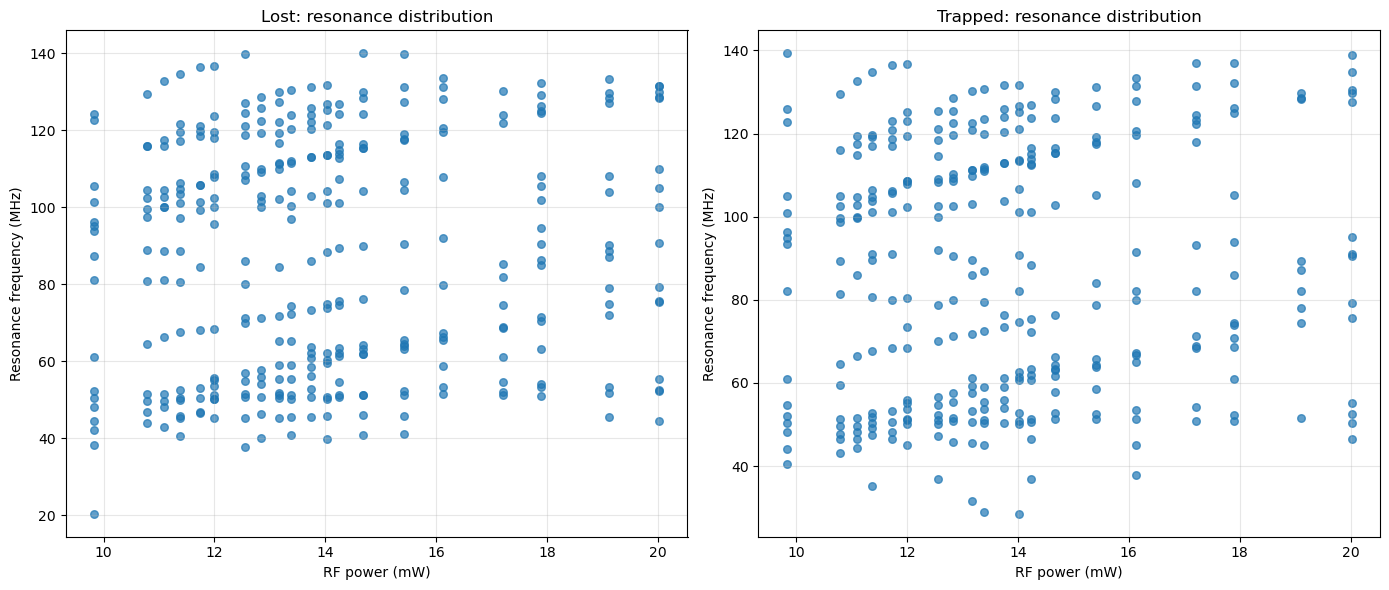

In [4]:
mu_cols = [f"mu{i}" for i in range(1, 19)]


def plot_resonance_distribution(data, title, ax=None):
    """Plot all resonance frequencies (mu) vs RF power (act_RF_mW)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    x_vals = []
    y_vals = []
    for _, row in data.iterrows():
        rf_mw = row["act_RF_mW"]
        for c in mu_cols:
            mu = row[c]
            if pd.notna(mu):
                x_vals.append(rf_mw)
                y_vals.append(mu)
    ax.scatter(x_vals, y_vals, alpha=0.7, s=30)
    ax.set_xlabel("RF power (mW)")
    ax.set_ylabel("Resonance frequency (MHz)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)


fig, (ax_lost, ax_trapped) = plt.subplots(1, 2, figsize=(14, 6))
plot_resonance_distribution(df_lost, "Lost: resonance distribution", ax_lost)
plot_resonance_distribution(df_trapped, "Trapped: resonance distribution", ax_trapped)
plt.tight_layout()
plt.show()

# Data cleaning

### 1. Recover split_x (segment cut point)

Fitting splits the spectrum at baseline; left (x ≤ split_x) and right (x > split_x) are fitted separately. Without split_x, merged peak params cannot correctly regenerate the stitched curve. Recover from peak positions (largest gap in sorted mus).

In [5]:
from recover_split_x import (
    add_split_x_to_dataframe,
    add_baseline_recovery_to_dataframe,
)

# 1) Recover split_x from merged mus (no raw data needed)
add_split_x_to_dataframe(df, format="averaged")

# 2) Recover baseline_* and y_min/y_max from raw data (load + split only, no fitting)
add_baseline_recovery_to_dataframe(df, data_root=None, format="averaged")

# Re-split to update df_lost, df_trapped
df_lost = df[df["mode"] == "lost"].reset_index(drop=True)
df_trapped = df[df["mode"] == "trapped"].reset_index(drop=True)

# Sanity check
print("Recovered split_x_MHz and baseline (first 2 rows lost):")
cols = [
    "RF_set_dBm", "act_RF_mW", "split_x_MHz",
    "baseline_left_mean", "baseline_left_std",
    "baseline_right_mean", "baseline_right_std",
    "y_min", "y_max"]
print(df_lost[[c for c in cols if c in df_lost.columns]].head(2))

Recovered split_x_MHz and baseline (first 2 rows lost):
   RF_set_dBm  act_RF_mW  split_x_MHz  baseline_left_mean  baseline_left_std  \
0        -0.5   9.830563    71.038937            0.015934           0.000904   
1         0.0  10.790574    72.643508            0.023650           0.001368   

   baseline_right_mean  baseline_right_std     y_min     y_max  
0             0.015542            0.000860  0.013981  0.079764  
1             0.024683            0.002263  0.020488  0.102772  


### 2. Filter resonances

1. Normalize each resonance amp by (y_max - y_min)
2. Filter out where |amp_norm|/sigma < 0.02 (set amp, mu, sigma to NaN)
3. Result: df_trapped_filtered, df_lost_filtered

In [6]:
TUNING_AMP_SIGMA_THRESH = False
AMP_SIGMA_THRESH = 0.08  # filter out if |amp_norm|/sigma < this
mu_cols = [f"mu{i}" for i in range(1, 19)]


def filter_resonances(data):
    """Filter: normalize amp by (y_max - y_min), drop where |amp_norm|/sigma < 0.02."""
    out = data.copy()
    y_range = (out["y_max"] - out["y_min"]).values
    y_range = np.where(y_range > 1e-12, y_range, 1.0)  # avoid div by zero

    for i in range(1, 19):
        ac, mc, sc = f"amp{i}", f"mu{i}", f"sigma{i}"
        if ac not in out.columns:
            continue
        amp = out[ac].values.astype(float)
        sigma = out[sc].values.astype(float)
        amp_norm = amp / y_range
        sigma_safe = np.where(np.abs(sigma) > 1e-12, sigma, np.nan)
        ratio = np.abs(amp_norm) / sigma_safe
        mask_drop = (ratio < AMP_SIGMA_THRESH) | pd.isna(ratio)
        out.loc[mask_drop, [ac, mc, sc]] = np.nan

    return out


df_lost_filtered = filter_resonances(df_lost)
df_trapped_filtered = filter_resonances(df_trapped)

df_lost_filtered.head()

,timestamp,mode,U2,RF_set_dBm,RF_set_mW,RF_meas_dBm,act_RF_mW,line_id,rep,min_scan,...,amp18,mu18,sigma18,split_x_MHz,baseline_left_mean,baseline_left_std,baseline_right_mean,baseline_right_std,y_min,y_max
0,averaged,lost,-0.35,-0.5,0.891251,9.925784,9.830563,0,avg,20.0,...,NaN,NaN,NaN,71.038937,0.015934,0.000904,0.015542,0.000860,0.013981,0.079764
1,averaged,lost,-0.35,0.0,1.000000,10.330446,10.790574,0,avg,20.0,...,NaN,NaN,NaN,72.643508,0.023650,0.001368,0.024683,0.002263,0.020488,0.102772
2,averaged,lost,-0.35,0.2,1.047129,10.450421,11.092823,0,avg,20.0,...,NaN,NaN,NaN,125.102762,0.018657,0.001147,0.018542,0.001080,0.016198,0.098643
3,averaged,lost,-0.35,0.4,1.096478,10.560865,11.378540,0,avg,20.0,...,0.007219,121.677166,0.55603,60.038402,0.017568,0.001892,0.017037,0.001820,0.013308,0.105172
4,averaged,lost,-0.35,0.6,1.148154,10.694586,11.734339,0,avg,20.0,...,NaN,NaN,NaN,76.411396,0.016270,0.001367,0.017360,0.001636,0.014164,0.093990


#### Code cell for param tuning for `AMP_SIGMA_THRES`

In [7]:
if TUNING_AMP_SIGMA_THRESH:
    import os
    from fitting_functions import gaussian_sum
    from data_io import load_and_average_group, get_data_root
    from metadata import build_tickling_groups, filter_excluded_timestamps
    from config import EXCLUDE_DATES

    OUT_PLOT_DIR = "outputs/filter_check_plots"
    os.makedirs(OUT_PLOT_DIR, exist_ok=True)

    def build_pred(x, peaks, c0):
        params = [c0] + [v for p in peaks for v in p]
        return gaussian_sum(np.asarray(x, dtype=float), *params) if params else np.full_like(x, c0)

    groups, _, _ = build_tickling_groups()
    rf_col = "RF_set_dBm" if "RF_set_dBm" in df_lost_filtered.columns else "RF_amplitude"

    for mode_name, dataf in [("lost", df_lost_filtered), ("trapped", df_trapped_filtered)]:
        for row_idx in range(len(dataf)):
            row = dataf.iloc[row_idx]
            split_x = row["split_x_MHz"]
            c0 = row["c0"] if pd.notna(row.get("c0")) else 0.0
            rf_val = float(row[rf_col])

            peaks_left, peaks_right = [], []
            for i in range(1, 19):
                a, m, s = row.get(f"amp{i}"), row.get(f"mu{i}"), row.get(f"sigma{i}")
                if pd.isna(a) or pd.isna(m) or pd.isna(s):
                    continue
                p = (float(a), float(m), float(s))
                (peaks_left if float(m) <= split_x else peaks_right).append(p)

            ts_list = []
            for g in groups:
                if g["RF_amplitude"] is not None and np.isclose(float(g["RF_amplitude"]), rf_val, atol=1e-6):
                    ts_list = filter_excluded_timestamps(g["timestamps"], EXCLUDE_DATES)
                    break
            if not ts_list:
                continue
            try:
                x_raw, ys = load_and_average_group(ts_list, data_root=get_data_root(None))
                y_raw = np.asarray(ys["ratio_signal"] if mode_name == "trapped" else ys["ratio_lost"])
            except Exception:
                continue
            if len(x_raw) == 0:
                continue

            x_smooth = np.linspace(x_raw.min(), x_raw.max(), 500)
            mask_sl = x_smooth <= split_x
            mask_sr = x_smooth > split_x
            y_smooth_l = build_pred(x_smooth[mask_sl], peaks_left, c0)
            y_smooth_r = build_pred(x_smooth[mask_sr], peaks_right, c0)
            x_fit = np.concatenate([x_smooth[mask_sl], x_smooth[mask_sr]])
            y_fit = np.concatenate([y_smooth_l, y_smooth_r])

            fig, ax = plt.subplots(figsize=(12, 5))
            ax.scatter(x_raw, y_raw, s=8, alpha=0.7, label="raw")
            ax.plot(x_fit, y_fit, "r-", lw=1.5, label="filtered fit (stitched)")
            ax.axvline(split_x, color="gray", ls="--", lw=1, label=f"split @ {split_x:.1f} MHz")
            ax.set_xlabel("Frequency (MHz)")
            ax.set_ylabel("Ratio")
            ax.set_title(f"{mode_name} row{row_idx} RF={rf_val}dBm L={len(peaks_left)} R={len(peaks_right)}")
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            fn = os.path.join(OUT_PLOT_DIR, f"{mode_name}_row{row_idx}_RF{rf_val:.2f}.png".replace(".", "p").replace("-", "m"))
            plt.savefig(fn, dpi=120)
            plt.close()

    print(f"Saved plots to {OUT_PLOT_DIR}/")

### 3. Group the filtered peaks

In [8]:
# Peak grouping by overlap: |mu1-mu2| <= K*sqrt(sigma1^2+sigma2^2), K=1
# Applied to filtered data. Left/right grouped separately; peaks sorted by mu, scanned low->high.
from peak_grouping import group_overlapping_peaks

TUNING_OVERLAP_K = False
OVERLAP_K = 3.0

def get_peak_groups_for_row(row, K=OVERLAP_K):
    """Build peaks_left, peaks_right from row (same as plot logic), return (groups_left, groups_right).
    Each group is a list of original indices into that side's peak list."""
    split_x = row["split_x_MHz"]
    peaks_left, peaks_right = [], []
    for i in range(1, 19):
        a, m, s = row.get(f"amp{i}"), row.get(f"mu{i}"), row.get(f"sigma{i}")
        if pd.isna(a) or pd.isna(m) or pd.isna(s):
            continue
        p = (float(a), float(m), float(s))
        (peaks_left if float(m) <= split_x else peaks_right).append(p)
    groups_left = group_overlapping_peaks(peaks_left, K=K)
    groups_right = group_overlapping_peaks(peaks_right, K=K)
    return groups_left, groups_right

# Attach group columns to filtered data
for name, df in [("lost", df_lost_filtered), ("trapped", df_trapped_filtered)]:
    glist, rlist = [], []
    for idx in range(len(df)):
        gl, gr = get_peak_groups_for_row(df.iloc[idx])
        glist.append(gl)
        rlist.append(gr)
    df["groups_left"] = glist
    df["groups_right"] = rlist

# Example
row0 = df_lost_filtered.iloc[0]
print("Example (first lost row): n_groups_left =", len(row0["groups_left"]), "n_groups_right =", len(row0["groups_right"]))
print("groups_left:", row0["groups_left"], "groups_right:", row0["groups_right"])

Example (first lost row): n_groups_left = 2 n_groups_right = 3
groups_left: [[0, 1, 3, 4, 5], [2]] groups_right: [[0, 3, 4], [1], [2, 5]]


#### Parameter tuning for `OVERLAP_K`

In [9]:
# Plot group ranges (background shading) + filtered fit for tuning K
# Group range = union of [mu-K*sigma, mu+K*sigma] for peaks in the group (same scale as overlap criterion)
if TUNING_OVERLAP_K:
    import os
    from fitting_functions import gaussian_sum
    from data_io import load_and_average_group, get_data_root
    from metadata import build_tickling_groups, filter_excluded_timestamps
    from config import EXCLUDE_DATES

    OUT_GROUP_PLOT_DIR = "outputs/group_check_plots"
    os.makedirs(OUT_GROUP_PLOT_DIR, exist_ok=True)

    def build_pred(x, peaks, c0):
        params = [c0] + [v for p in peaks for v in p]
        return gaussian_sum(np.asarray(x, dtype=float), *params) if params else np.full_like(x, c0)

    def group_range(peaks, group_indices, K=OVERLAP_K):
        """Union of [mu-K*sigma, mu+K*sigma] for peaks at group_indices."""
        if not group_indices:
            return None, None
        lefts = [peaks[i][1] - K * peaks[i][2] for i in group_indices]
        rights = [peaks[i][1] + K * peaks[i][2] for i in group_indices]
        return min(lefts), max(rights)

    groups_meta, _, _ = build_tickling_groups()
    rf_col = "RF_set_dBm" if "RF_set_dBm" in df_lost_filtered.columns else "RF_amplitude"
    GROUP_COLORS = ["#ffcccc", "#ccffcc", "#ccccff", "#ffffcc", "#ffccff", "#ccffff"]  # light RGB for groups

    for mode_name, dataf in [("lost", df_lost_filtered), ("trapped", df_trapped_filtered)]:
        for row_idx in range(len(dataf)):
            row = dataf.iloc[row_idx]
            split_x = row["split_x_MHz"]
            c0 = row["c0"] if pd.notna(row.get("c0")) else 0.0
            rf_val = float(row[rf_col])

            peaks_left, peaks_right = [], []
            for i in range(1, 19):
                a, m, s = row.get(f"amp{i}"), row.get(f"mu{i}"), row.get(f"sigma{i}")
                if pd.isna(a) or pd.isna(m) or pd.isna(s):
                    continue
                p = (float(a), float(m), float(s))
                (peaks_left if float(m) <= split_x else peaks_right).append(p)

            g_l, g_r = row["groups_left"], row["groups_right"]

            ts_list = []
            for g in groups_meta:
                if g["RF_amplitude"] is not None and np.isclose(float(g["RF_amplitude"]), rf_val, atol=1e-6):
                    ts_list = filter_excluded_timestamps(g["timestamps"], EXCLUDE_DATES)
                    break
            if not ts_list:
                continue
            try:
                x_raw, ys = load_and_average_group(ts_list, data_root=get_data_root(None))
            except Exception:
                continue
            if len(x_raw) == 0:
                continue

            x_smooth = np.linspace(x_raw.min(), x_raw.max(), 500)
            mask_sl = x_smooth <= split_x
            mask_sr = x_smooth > split_x
            y_smooth_l = build_pred(x_smooth[mask_sl], peaks_left, c0)
            y_smooth_r = build_pred(x_smooth[mask_sr], peaks_right, c0)
            x_fit = np.concatenate([x_smooth[mask_sl], x_smooth[mask_sr]])
            y_fit = np.concatenate([y_smooth_l, y_smooth_r])

            fig, ax = plt.subplots(figsize=(12, 5))
            ymin_ax, ymax_ax = y_fit.min() - 0.01, y_fit.max() + 0.01

            for ig, grp in enumerate(g_l):
                lo, hi = group_range(peaks_left, grp)
                if lo is not None:
                    ax.axvspan(lo, hi, alpha=0.35, color=GROUP_COLORS[ig % len(GROUP_COLORS)], zorder=0)
            for ig, grp in enumerate(g_r):
                lo, hi = group_range(peaks_right, grp)
                if lo is not None:
                    ax.axvspan(lo, hi, alpha=0.35, color=GROUP_COLORS[ig % len(GROUP_COLORS)], zorder=0)

            ax.plot(x_fit, y_fit, "r-", lw=1.5, label="filtered fit", zorder=5)
            ax.axvline(split_x, color="gray", ls="--", lw=1, label=f"split @ {split_x:.1f} MHz")
            ax.set_xlim(x_raw.min(), x_raw.max())
            ax.set_ylim(ymin_ax, ymax_ax)
            ax.set_xlabel("Frequency (MHz)")
            ax.set_ylabel("Ratio")
            ax.set_title(f"{mode_name} row{row_idx} RF={rf_val}dBm groups_L={len(g_l)} groups_R={len(g_r)}")
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            fn = os.path.join(OUT_GROUP_PLOT_DIR, f"{mode_name}_row{row_idx}_RF{rf_val:.2f}.png".replace(".", "p").replace("-", "m"))
            plt.savefig(fn, dpi=120)
            plt.close()

    print(f"Saved group check plots to {OUT_GROUP_PLOT_DIR}/")

### 4. Select real peaks by group

In [10]:
# Filter peaks: keep only composite local maxima with sufficient intensity and prominence
from peak_filtering import filter_peaks_by_composite_local_max

TUNING_SELECTION = False
INTENSITY_THRESH = 0.10   # |amp| / (y_max - y_min)
PROMINENCE_THRESH = 0.06  # prominence / (y_max - y_min)

df_lost_selected = pd.DataFrame([
    filter_peaks_by_composite_local_max(
        df_lost_filtered.iloc[idx],
        df_lost_filtered.iloc[idx]["groups_left"],
        df_lost_filtered.iloc[idx]["groups_right"],
        intensity_thresh=INTENSITY_THRESH,
        prominence_thresh=PROMINENCE_THRESH,
    )
    for idx in range(len(df_lost_filtered))
])
df_trapped_selected = pd.DataFrame([
    filter_peaks_by_composite_local_max(
        df_trapped_filtered.iloc[idx],
        df_trapped_filtered.iloc[idx]["groups_left"],
        df_trapped_filtered.iloc[idx]["groups_right"],
        intensity_thresh=INTENSITY_THRESH,
        prominence_thresh=PROMINENCE_THRESH,
    )
    for idx in range(len(df_trapped_filtered))
])

df_lost_selected.head()

,timestamp,mode,U2,RF_set_dBm,RF_set_mW,RF_meas_dBm,act_RF_mW,line_id,rep,min_scan,...,sigma18,split_x_MHz,baseline_left_mean,baseline_left_std,baseline_right_mean,baseline_right_std,y_min,y_max,groups_left,groups_right
0,averaged,lost,-0.35,-0.5,0.891251,9.925784,9.830563,0,avg,20.0,...,NaN,71.038937,0.015934,0.000904,0.015542,0.000860,0.013981,0.079764,"[[0, 1, 3, 4, 5], [2]]","[[0, 3, 4], [1], [2, 5]]"
1,averaged,lost,-0.35,0.0,1.000000,10.330446,10.790574,0,avg,20.0,...,NaN,72.643508,0.023650,0.001368,0.024683,0.002263,0.020488,0.102772,"[[0, 2, 3], [1]]","[[0, 1, 4, 5], [2], [3]]"
2,averaged,lost,-0.35,0.2,1.047129,10.450421,11.092823,0,avg,20.0,...,NaN,125.102762,0.018657,0.001147,0.018542,0.001080,0.016198,0.098643,"[[0, 2, 3], [1], [4, 5, 7, 8], [6]]",[[0]]
3,averaged,lost,-0.35,0.4,1.096478,10.560865,11.378540,0,avg,20.0,...,NaN,60.038402,0.017568,0.001892,0.017037,0.001820,0.013308,0.105172,"[[0, 1, 2, 3]]","[[0], [1, 5, 6, 7], [2, 3, 8], [4]]"
4,averaged,lost,-0.35,0.6,1.148154,10.694586,11.734339,0,avg,20.0,...,NaN,76.411396,0.016270,0.001367,0.017360,0.001636,0.014164,0.093990,"[[0, 2], [1]]","[[0, 3, 4], [1], [2]]"


#### Parameter tuning for `INTENSITY_THRESH` and `PROMINENCE_THRESH`

In [11]:
# Plot for tuning INTENSITY_THRESH and PROMINENCE_THRESH: kept peaks in color, dropped in gray
if TUNING_SELECTION:
    import os
    from fitting_functions import gaussian_sum
    from data_io import load_and_average_group, get_data_root
    from metadata import build_tickling_groups, filter_excluded_timestamps
    from config import EXCLUDE_DATES

    OUT_FILTER_TUNE_DIR = "outputs/intensity_prominence_tune_plots"
    os.makedirs(OUT_FILTER_TUNE_DIR, exist_ok=True)

    def build_pred(x, peaks, c0):
        params = [c0] + [v for p in peaks for v in p]
        return gaussian_sum(np.asarray(x, dtype=float), *params) if params else np.full_like(x, c0)

    groups_meta, _, _ = build_tickling_groups()
    rf_col = "RF_set_dBm" if "RF_set_dBm" in df_lost_filtered.columns else "RF_amplitude"
    COLOR_KEPT = "#ffdd00"     # bright yellow - selected
    COLOR_DROPPED = "#bbbbbb"  # light gray - filtered out

    for mode_name, dataf_filtered, dataf_selected in [
        ("lost", df_lost_filtered, df_lost_selected),
        ("trapped", df_trapped_filtered, df_trapped_selected),
    ]:
        for row_idx in range(len(dataf_filtered)):
            row_f = dataf_filtered.iloc[row_idx]
            row_selected = dataf_selected.iloc[row_idx]
            split_x = row_f["split_x_MHz"]
            c0 = row_f["c0"] if pd.notna(row_f.get("c0")) else 0.0
            rf_val = float(row_f[rf_col])

            peaks_left, peaks_right = [], []
            kept_left, kept_right = [], []
            for i in range(1, 19):
                a, m, s = row_f.get(f"amp{i}"), row_f.get(f"mu{i}"), row_f.get(f"sigma{i}")
                if pd.isna(a) or pd.isna(m) or pd.isna(s):
                    continue
                p = (float(a), float(m), float(s))
                kept = pd.notna(row_selected.get(f"mu{i}"))
                if float(m) <= split_x:
                    peaks_left.append(p)
                    kept_left.append(kept)
                else:
                    peaks_right.append(p)
                    kept_right.append(kept)

            ts_list = []
            for g in groups_meta:
                if g["RF_amplitude"] is not None and np.isclose(float(g["RF_amplitude"]), rf_val, atol=1e-6):
                    ts_list = filter_excluded_timestamps(g["timestamps"], EXCLUDE_DATES)
                    break
            if not ts_list:
                continue
            try:
                x_raw, _ = load_and_average_group(ts_list, data_root=get_data_root(None))
            except Exception:
                continue
            if len(x_raw) == 0:
                continue

            x_smooth = np.linspace(x_raw.min(), x_raw.max(), 500)
            mask_sl = x_smooth <= split_x
            mask_sr = x_smooth > split_x
            y_smooth_l = build_pred(x_smooth[mask_sl], peaks_left, c0)
            y_smooth_r = build_pred(x_smooth[mask_sr], peaks_right, c0)
            x_fit = np.concatenate([x_smooth[mask_sl], x_smooth[mask_sr]])
            y_fit = np.concatenate([y_smooth_l, y_smooth_r])
            ymin_ax, ymax_ax = y_fit.min() - 0.01, y_fit.max() + 0.01

            fig, ax = plt.subplots(figsize=(12, 5))
            ax.plot(x_fit, y_fit, "k-", lw=1.2, label="filtered fit", zorder=5)
            ax.axvline(split_x, color="gray", ls="--", lw=1)
            mus, ys, colors = [], [], []
            for (amp, mu, sigma), kept in zip(peaks_left, kept_left):
                mus.append(mu)
                ys.append(np.interp(mu, x_fit, y_fit))
                colors.append(COLOR_KEPT if kept else COLOR_DROPPED)
            for (amp, mu, sigma), kept in zip(peaks_right, kept_right):
                mus.append(mu)
                ys.append(np.interp(mu, x_fit, y_fit))
                colors.append(COLOR_KEPT if kept else COLOR_DROPPED)
            for mu, y, c in zip(mus, ys, colors):
                ax.scatter(mu, y, marker="D", s=80, c=c, edgecolors="k", linewidths=0.5, zorder=10)
            n_kept = sum(kept_left) + sum(kept_right)
            n_total = len(kept_left) + len(kept_right)
            ax.set_xlim(x_raw.min(), x_raw.max())
            ax.set_ylim(ymin_ax, ymax_ax)
            ax.set_xlabel("Frequency (MHz)")
            ax.set_ylabel("Ratio")
            ax.set_title(f"{mode_name} row{row_idx} RF={rf_val}dBm kept={n_kept}/{n_total} (yellow=kept, gray=dropped)")
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            fn = os.path.join(OUT_FILTER_TUNE_DIR, f"{mode_name}_row{row_idx}_RF{rf_val:.2f}.png".replace(".", "p").replace("-", "m"))
            plt.savefig(fn, dpi=120)
            plt.close()

    print(f"Saved intensity/prominence tune plots to {OUT_FILTER_TUNE_DIR}/")

### 5. Final formal cleanup for dataset

In [12]:
# Final cleanup: compact peaks 1,2,3,..., drop all-NaN columns, remove pure metadata
METADATA_DROP = [
    "mode", "timestamp", "line_id", "rep",
    "min_scan", "max_scan",
    "groups_left", "groups_right"
]
PEAK_COLS = [f"{p}{i}" for i in range(1, 19) for p in ("amp", "mu", "sigma")]

def _to_final(df_selected):
    out_rows = []
    for idx in range(len(df_selected)):
        row = df_selected.iloc[idx]
        peaks = []
        for i in range(1, 19):
            a, m, s = row.get(f"amp{i}"), row.get(f"mu{i}"), row.get(f"sigma{i}")
            if pd.notna(a) and pd.notna(m) and pd.notna(s):
                peaks.append((float(a), float(m), float(s)))
        # Sort peaks by mu (center frequency) so amp1,mu1,sigma1 has smallest mu, etc.
        peaks = sorted(peaks, key=lambda x: x[1])
        new_row = {k: row[k] for k in row.index if k not in PEAK_COLS}
        for k in METADATA_DROP:
            new_row.pop(k, None)
        for j, (a, m, s) in enumerate(peaks, 1):
            new_row[f"amp{j}"] = a
            new_row[f"mu{j}"] = m
            new_row[f"sigma{j}"] = s
        new_row["n_peaks"] = len(peaks)
        out_rows.append(new_row)
    df_out = pd.DataFrame(out_rows)
    max_n = max(r["n_peaks"] for r in out_rows)
    for i in range(max_n + 1, 19):
        for p in ("amp", "mu", "sigma"):
            c = f"{p}{i}"
            df_out = df_out.drop(columns=[c], errors="ignore")
    return df_out

df_lost_final = _to_final(df_lost_selected)
df_trapped_final = _to_final(df_trapped_selected)
print("df_lost_final shape:", df_lost_final.shape)
print("df_trapped_final shape:", df_trapped_final.shape)
print("Columns:", list(df_lost_final.columns))
df_lost_final.head()

# Output final dataframes to CSV
df_lost_final.to_csv("data/df_lost_final.csv", index=False)
df_trapped_final.to_csv("data/df_trapped_final.csv", index=False)
print("Exported: data/df_lost_final.csv, data/df_trapped_final.csv")


df_lost_final shape: (20, 40)
df_trapped_final shape: (20, 40)
Columns: ['U2', 'RF_set_dBm', 'RF_set_mW', 'RF_meas_dBm', 'act_RF_mW', 'n_peaks', 'r2', 'aicc', 'c0', 'split_x_MHz', 'baseline_left_mean', 'baseline_left_std', 'baseline_right_mean', 'baseline_right_std', 'y_min', 'y_max', 'amp1', 'mu1', 'sigma1', 'amp2', 'mu2', 'sigma2', 'amp3', 'mu3', 'sigma3', 'amp4', 'mu4', 'sigma4', 'amp5', 'mu5', 'sigma5', 'amp6', 'mu6', 'sigma6', 'amp7', 'mu7', 'sigma7', 'amp8', 'mu8', 'sigma8']
Exported: df_lost_final.csv, df_trapped_final.csv


# Generate plots for cleaned data

Plotting: lost 20 rows, trapped 19 rows


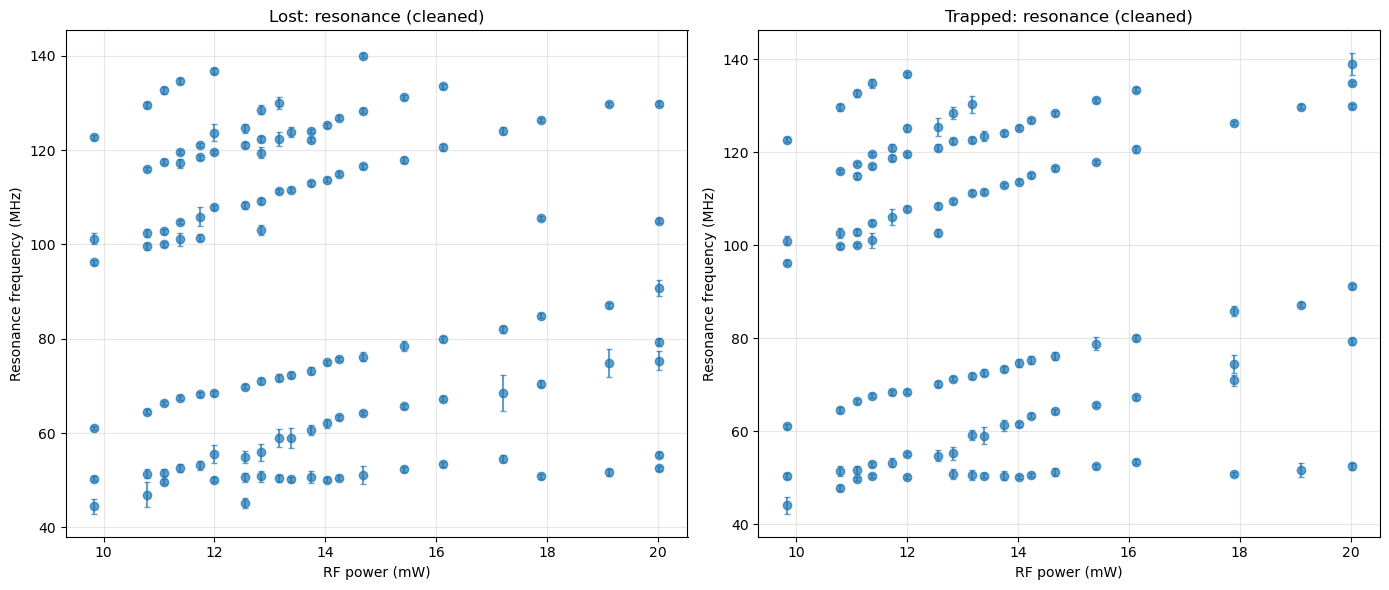

In [13]:
# Manual row exclusion (edit before running)
EXCLUDE_ROWS = []  # e.g. [("lost", 5), ("trapped", 3)]
EXCLUDE_TRAPPED_RF_dBm = [4.3]  # exclude trapped rows where RF_set_dBm in this list

def apply_exclusions(df_lost, df_trapped):
    lost, trapped = df_lost.copy(), df_trapped.copy()
    for mode, row_idx in EXCLUDE_ROWS:
        if mode == "lost" and row_idx in lost.index:
            lost = lost.drop(index=row_idx).reset_index(drop=True)
        elif mode == "trapped" and row_idx in trapped.index:
            trapped = trapped.drop(index=row_idx).reset_index(drop=True)
    if EXCLUDE_TRAPPED_RF_dBm:
        rc = "RF_set_dBm" if "RF_set_dBm" in trapped.columns else "RF_amplitude"
        trapped = trapped[~trapped[rc].isin(EXCLUDE_TRAPPED_RF_dBm)].reset_index(drop=True)
    return lost, trapped

df_lost_plot, df_trapped_plot = apply_exclusions(df_lost_final, df_trapped_final)
print(f"Plotting: lost {len(df_lost_plot)} rows, trapped {len(df_trapped_plot)} rows")

mu_cols_plot = [c for c in df_lost_plot.columns if c.startswith("mu") and len(c) > 2 and c[2:].isdigit()]

def plot_resonance_distribution_cleaned(data, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    rc = "act_RF_mW" if "act_RF_mW" in data.columns else "RF_set_mW"
    xv, yv, yerr = [], [], []
    for _, row in data.iterrows():
        for i, c in enumerate(mu_cols_plot):
            mu = row.get(c)
            if pd.notna(mu):
                sigma_col = "sigma" + c[2:]
                sig = row.get(sigma_col)
                sig = float(sig) if pd.notna(sig) else 0.0
                xv.append(row[rc]); yv.append(mu); yerr.append(sig)
    ax.errorbar(xv, yv, yerr=yerr, fmt="o", alpha=0.7, ms=6, capsize=2, capthick=1)
    ax.set_xlabel("RF power (mW)"); ax.set_ylabel("Resonance frequency (MHz)")
    ax.set_title(title); ax.grid(True, alpha=0.3)

fig, (ax_l, ax_t) = plt.subplots(1, 2, figsize=(14, 6))
plot_resonance_distribution_cleaned(df_lost_plot, "Lost: resonance (cleaned)", ax_l)
plot_resonance_distribution_cleaned(df_trapped_plot, "Trapped: resonance (cleaned)", ax_t)
plt.tight_layout(); plt.show()